In [176]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from arch import arch_model
from scipy.stats import chi2, jarque_bera
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA

In [178]:
import numpy as np
from scipy.stats import chi2

def mcleod_li_test(residuals, k):
    """
    Calculates the McLeod-Li test statistic for a time series with k lags.
    Returns the test statistic and its p-value.
    
    H0: No significant autocorrelation in the squared residuals --> Homocedasticity.
    Args:
        - residuals: residuals serie
        - k (int): lags
    Return:
        - stat
        - p-value
    """
    n = len(residuals)
    residuals_sq = residuals ** 2

    x_sum = np.sum(residuals_sq)
    x_lag_sum = np.sum(residuals_sq[k:])  # sum from index k to n

    test_stat = (n * (n + 2) * x_lag_sum) / (x_sum ** 2)
    
    df = k
    
    p_value = 1 - chi2.cdf(test_stat, df)
    
    return test_stat, p_value


Data

In [206]:
start_date = "2020-11-01"
end_date   = "2024-12-31"

ticker = "SPY"

stock = yf.Ticker(ticker)
hist = stock.history(start = start_date, end = end_date)
df = pd.DataFrame(hist, columns=['Close'])

In [207]:
# Convert prices to log returns 
df['log_return'] = np.log(df['Close']).diff() * 100
df.dropna(inplace=True)

Text(0.5, 1.0, 'Returns of SPY')

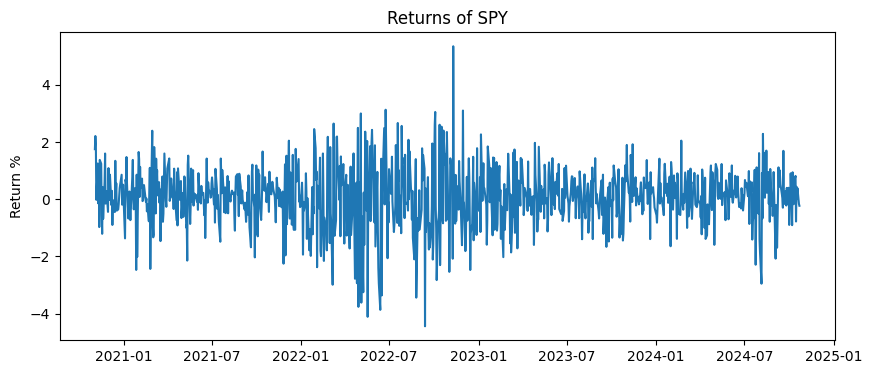

In [208]:
# Add trace plot
plt.figure(figsize=(10,4))
plt.plot(df['log_return'])
plt.ylabel("Return %")
plt.title(f'Returns of {ticker}')

Model

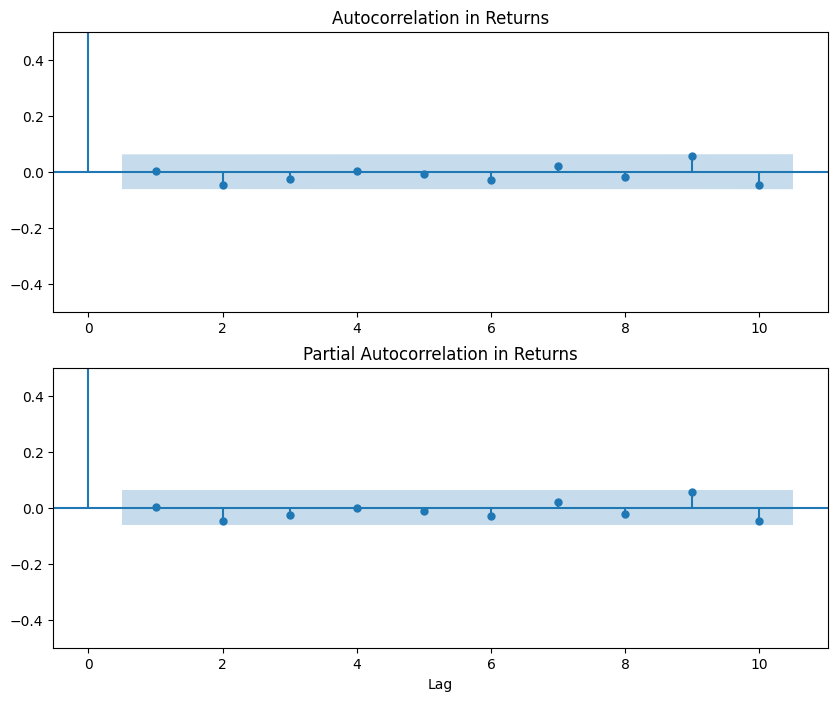

In [209]:
diff_ts = df['log_return'].iloc[1:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(diff_ts, ax=ax1, lags=10)
ax1.set_ylim(-0.5, .5) 
ax1.set_title("Autocorrelation in Returns")
plot_pacf(diff_ts, ax=ax2, lags=10)
ax2.set_ylim(-0.5, .5)  
ax2.set_xlabel("Lag")  
ax2.set_title("Partial Autocorrelation in Returns")

plt.show()

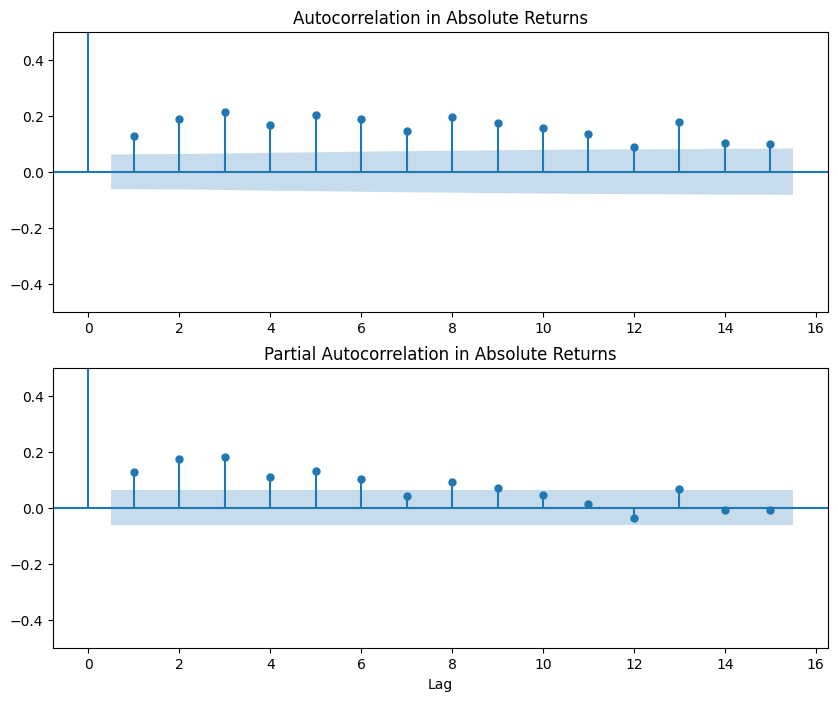

In [210]:
# Compute absolute returns: measure magnitude
abs_returns = diff_ts.abs()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(abs_returns, ax=ax1, lags=15)
ax1.set_ylim(-.5, .5) 
ax1.set_title("Autocorrelation in Absolute Returns")
plot_pacf(abs_returns, ax=ax2, lags=15)
ax2.set_ylim(-.5, .5)  
ax2.set_title("Partial Autocorrelation in Absolute Returns")
ax2.set_xlabel("Lag")  

plt.show()

In [8]:
# test_stat, p_value = mcleod_li_test(abs_returns, 50)
# print("McLeod-Li test statistic: ", test_stat)
# print("p-value: ", p_value)

# if p_value < 0.05:
#     print("Reject H0: No significant autocorrelation in the squared residuals. (Heterocedasticity)")
# else:
#     print("No reject H0: No significant autocorrelation in the squared residuals. (Homocedasticity)")

Train Test split

In [211]:
y_train, y_test = train_test_split(diff_ts, train_size=0.85, shuffle=False)

Model

In [212]:
import pandas as pd
from tqdm import tqdm 
from arch import arch_model

results_list = []

p_values      = [1, 2, 3, 4, 5, 6, 7, 8, 9]
q_values      = [1, 2, 3, 4, 5, 6, 7, 8, 9]
means         = ['Zero', 'AR']
distributions = ['normal', 't', 'skewstudent']

total_iterations = len(p_values) * len(q_values) * len(distributions)

with tqdm(total=total_iterations, desc='Fitting GARCH Models') as pbar:
    for p in p_values:
        for q in q_values:
            for mean in means:
                for dist in distributions:
                    model = arch_model(y_train, mean=mean, vol='Garch', p=p, q=q, dist=dist, rescale=False)
                    res = model.fit(disp='off')
                    
                    results_list.append([
                        f'GARCH({p},{q})', p, q, mean, dist, res.aic, res.bic])
                    
                    pbar.update(1)

results = pd.DataFrame(results_list, columns=['Model', 'p', 'q', 'mean', 'Dist', 'AIC', 'BIC'])

best_model_aic = results.loc[results['AIC'].idxmin()]
best_model_bic = results.loc[results['BIC'].idxmin()]


Fitting GARCH Models: 486it [00:54,  8.89it/s]                         


In [213]:
print("Best model based on AIC:")
print(best_model_aic)

print("\nBest model based on BIC:")
print(best_model_bic)

Best model based on AIC:
Model     GARCH(1,1)
p                  1
q                  1
mean              AR
Dist     skewstudent
AIC      2362.376307
BIC      2390.826512
Name: 5, dtype: object

Best model based on BIC:
Model     GARCH(1,1)
p                  1
q                  1
mean              AR
Dist               t
AIC      2364.561712
BIC      2388.270216
Name: 4, dtype: object


In [214]:
# Fit GARCH (1,1)
# y_train, y_test = train_test_split(abs_returns, train_size= 0.8)

garch_mod = arch_model(y_train, mean = "AR",  vol='Garch', p=1, q=1, rescale=False)
res_garch = garch_mod.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4627.243376875012
Iteration:      2,   Func. Count:     15,   Neg. LLF: 85693804108.70128
Iteration:      3,   Func. Count:     23,   Neg. LLF: 2529009.8651983207
Iteration:      4,   Func. Count:     29,   Neg. LLF: 1184.7693334925598
Iteration:      5,   Func. Count:     35,   Neg. LLF: 1450.5344553638943
Iteration:      6,   Func. Count:     41,   Neg. LLF: 1193.9746267349433
Iteration:      7,   Func. Count:     47,   Neg. LLF: 1181.799627295016
Iteration:      8,   Func. Count:     53,   Neg. LLF: 1181.2392816120177
Iteration:      9,   Func. Count:     58,   Neg. LLF: 1181.2364967970502
Iteration:     10,   Func. Count:     63,   Neg. LLF: 1181.2364647799047
Iteration:     11,   Func. Count:     68,   Neg. LLF: 1181.2364630626762
Iteration:     12,   Func. Count:     72,   Neg. LLF: 1181.2364630628513
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1181.2364630626762
            Iterat

In [215]:
# Model summary 
print(res_garch.summary())

                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1181.24
Distribution:                  Normal   AIC:                           2370.47
Method:            Maximum Likelihood   BIC:                           2389.44
                                        No. Observations:                  847
Date:                Tue, Oct 22 2024   Df Residuals:                      846
Time:                        17:37:29   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const          0.0856  3.035e-02      2.820  4.801e-03 [2.611e-0

Predictions - Normal

In [216]:
# Forecast the test set = All periods ahead 
yhat = res_garch.forecast(horizon = y_test.shape[0], reindex=True)

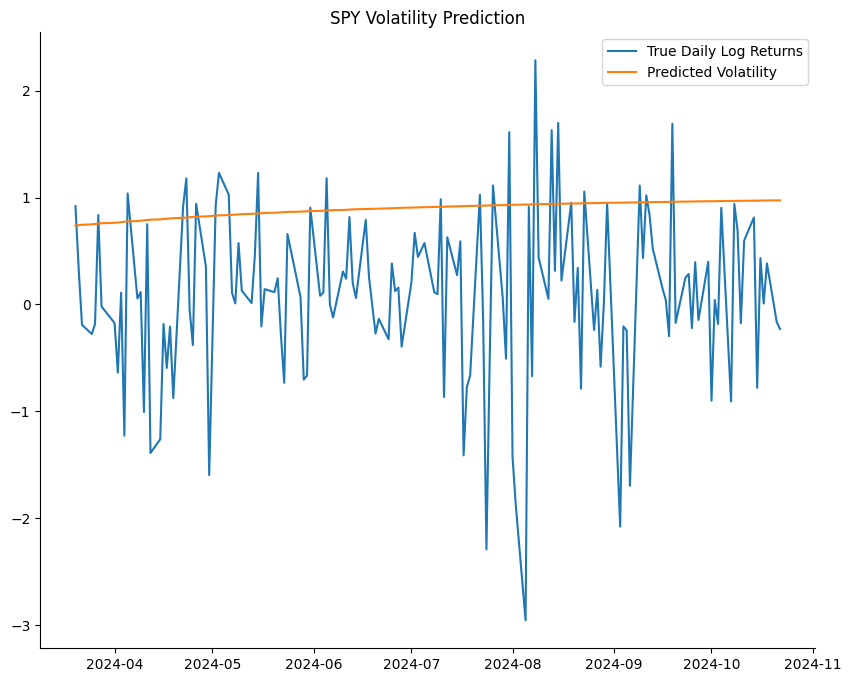

In [217]:
fig,ax = plt.subplots(figsize=(10,8))
ax.spines[['top','right']].set_visible(False)
# Plot test set returns
plt.plot(diff_ts[-y_test.shape[0]:])
# Plot volatility estimates for test set
plt.plot(y_test.index, np.sqrt(yhat.variance.values[-1,:]))
plt.title(f'{ticker} Volatility Prediction')
plt.legend(['True Daily Log Returns', 'Predicted Volatility'])

In [218]:
# Predict one step ahead

rolling_preds = []

for i in range(y_test.shape[0]):
    train = y_train[:-(y_test.shape[0]-i)]
    model = arch_model(train, p=1, q=1, rescale = False, mean="AR")
    model_fit = model.fit(disp='off')
    # One step ahead predictor
    pred = model_fit.forecast(horizon=1, reindex=True)
    rolling_preds.append(np.sqrt(pred.variance.values[-1,:][0]))

rolling_preds = pd.Series(rolling_preds, index=y_test.index)

Text(0.5, 1.0, 'SPY Rolling Volatility Prediction')

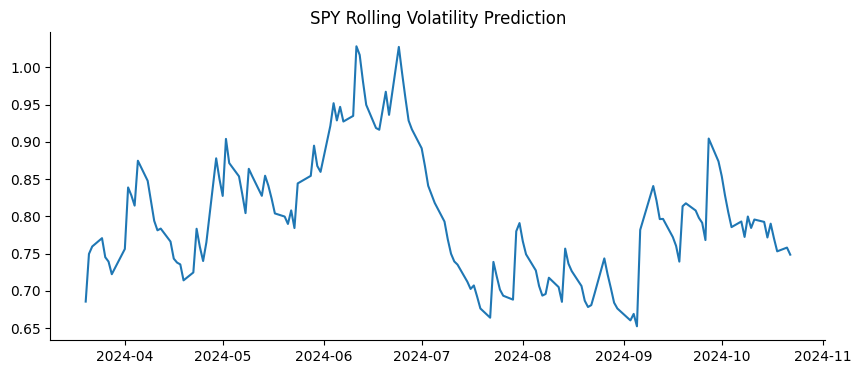

In [219]:
# Plot of predicted test data rolling volatility predictions
fig,ax = plt.subplots(figsize=(10,4))
ax.spines[['top','right']].set_visible(False)
plt.plot(rolling_preds)
plt.title(f'{ticker} Rolling Volatility Prediction')

In [82]:
# # Compare n-step-ahead and one-step-ahead rolling predictions

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
# ax1.spines[['top','right']].set_visible(False)
# ax1.plot(diff_ts[-y_test.shape[0]:])
# ax1.plot(y_test.index, np.sqrt(yhat.variance.values[-1,:]))
# ax1.set_title("S&P 500 Volatility N-Step Predictions")
# ax1.legend(['True Daily Returns', 'Predicted Volatility'])

# ax.spines[['top','right']].set_visible(False)
# ax2.plot(diff_ts[-y_test.shape[0]:])
# ax2.plot(y_test.index,rolling_preds)
# ax2.set_title("S&P 500 Volatility Rolling Predictions")
# ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])
# plt.show()

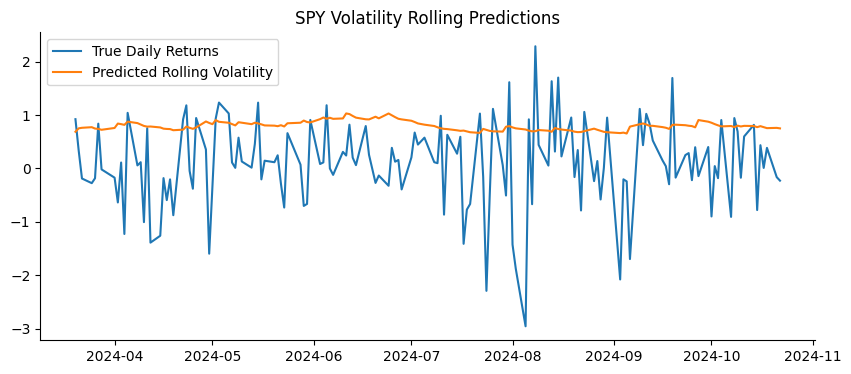

In [220]:
fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.spines[['top', 'right']].set_visible(False)

ax2.plot(diff_ts[-y_test.shape[0]:])
ax2.plot(y_test.index, rolling_preds)
ax2.set_title(f"{ticker} Volatility Rolling Predictions")
ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])

plt.show()


In [221]:
# Jarque-Bera test statistic

# H₀: The data has a normal distribution.
# Hₐ: The data does not have a normal distribution.

std_resid = res_garch.resid / res_garch.conditional_volatility

# Perform Jarque-Bera test using scipy.stats
jb_test = jarque_bera(std_resid)
print("Jarque-Bera test statistic:", jb_test[0])
print("p-value:", jb_test[1])

if jb_test[1].item() < 0.05:
    print("Reject H0: The data do not have statistical normal distribution")
else:
    print("No reject H0: Data have normal distribution.")

Jarque-Bera test statistic: 23.709494210727158
p-value: 7.104749134350761e-06
Reject H0: The data do not have statistical normal distribution


T-Student distribution

In [222]:
garch_mod = arch_model(y_train, mean = "AR",  vol='Garch', p=1, q=1, dist = 'skewstudent', rescale=False)
res_garch = garch_mod.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 5122.202363367321
Iteration:      2,   Func. Count:     19,   Neg. LLF: 70814.81087552241
Iteration:      3,   Func. Count:     29,   Neg. LLF: 95306.10429367692
Iteration:      4,   Func. Count:     37,   Neg. LLF: 1178.2393232275435
Iteration:      5,   Func. Count:     45,   Neg. LLF: 1180.547812565405
Iteration:      6,   Func. Count:     53,   Neg. LLF: 1179.3105982926622
Iteration:      7,   Func. Count:     61,   Neg. LLF: 1176.8945705730514
Iteration:      8,   Func. Count:     69,   Neg. LLF: 1175.415976879874
Iteration:      9,   Func. Count:     76,   Neg. LLF: 1176.8929848491953
Iteration:     10,   Func. Count:     84,   Neg. LLF: 1175.3068872975782
Iteration:     11,   Func. Count:     91,   Neg. LLF: 1175.229097490237
Iteration:     12,   Func. Count:     98,   Neg. LLF: 1175.1942687863718
Iteration:     13,   Func. Count:    105,   Neg. LLF: 1175.1888793230983
Iteration:     14,   Func. Count:    112,   Neg. LLF: 117

In [223]:
# Model summary 
print(res_garch.summary())

                                 AR - GARCH Model Results                                
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                                   AR   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -1175.19
Distribution:      Standardized Skew Student's t   AIC:                           2362.38
Method:                       Maximum Likelihood   BIC:                           2390.83
                                                   No. Observations:                  847
Date:                           Tue, Oct 22 2024   Df Residuals:                      846
Time:                                   17:38:28   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
----------------------------------------

In [224]:
# Predict one step ahead

rolling_preds = []

from tqdm import tqdm

for i in tqdm(range(y_test.shape[0]), desc="Predicting volatility"):
    train = y_train[:-(y_test.shape[0]-i)]
    model = arch_model(train, p=1, q=1, rescale=False, dist='skewstudent', mean="AR")
    model_fit = model.fit(disp='off')
    # One step ahead predictor
    pred = model_fit.forecast(horizon=1, reindex=True)
    rolling_preds.append(np.sqrt(pred.variance.values[-1,:][0]))

rolling_preds = pd.Series(rolling_preds, index=y_test.index)

Predicting volatility: 100%|██████████| 150/150 [00:06<00:00, 22.92it/s]


In [225]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, rolling_preds)
print("MSE:", mse)


MSE: 1.1287924372532547


Text(0.5, 1.0, 'SPY Rolling Volatility Prediction')

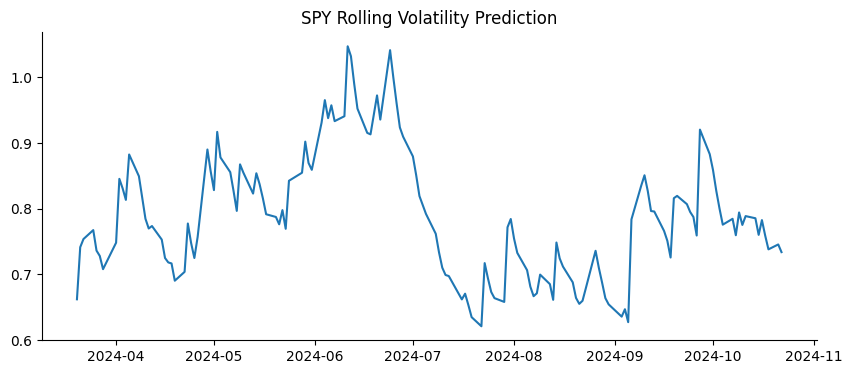

In [226]:
# Plot of predicted test data rolling volatility predictions
fig,ax = plt.subplots(figsize=(10,4))
ax.spines[['top','right']].set_visible(False)
plt.plot(rolling_preds)
plt.title(f'{ticker} Rolling Volatility Prediction')

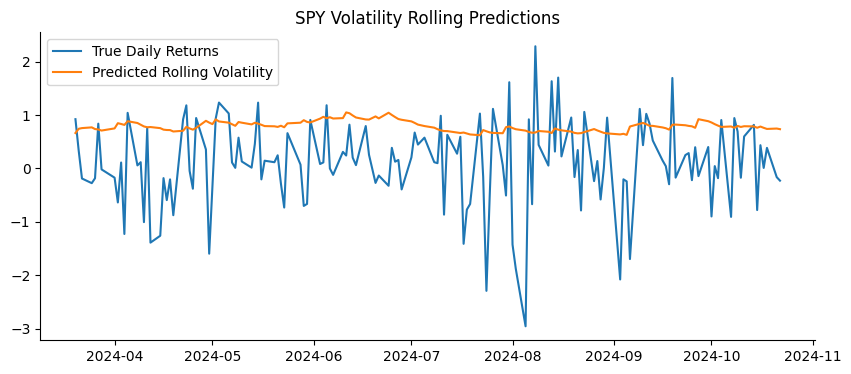

In [227]:
fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.spines[['top', 'right']].set_visible(False)

ax2.plot(diff_ts[-y_test.shape[0]:])
ax2.plot(y_test.index, rolling_preds)
ax2.set_title(f"{ticker} Volatility Rolling Predictions")
ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])

plt.show()


In [228]:
# Jarque-Bera test statistic

# H₀: The data has a normal distribution.
# Hₐ: The data does not have a normal distribution.

std_resid = res_garch.resid / res_garch.conditional_volatility

# Perform Jarque-Bera test using scipy.stats
jb_test = jarque_bera(std_resid)
print("Jarque-Bera test statistic:", jb_test[0])
print("p-value:", jb_test[1])

if jb_test[1].item() < 0.05:
    print("Reject H0: The data do not have statistical normal distribution")
else:
    print("No reject H0: Data have normal distribution.")

Jarque-Bera test statistic: 28.96157113080419
p-value: 5.141321181066749e-07
Reject H0: The data do not have statistical normal distribution


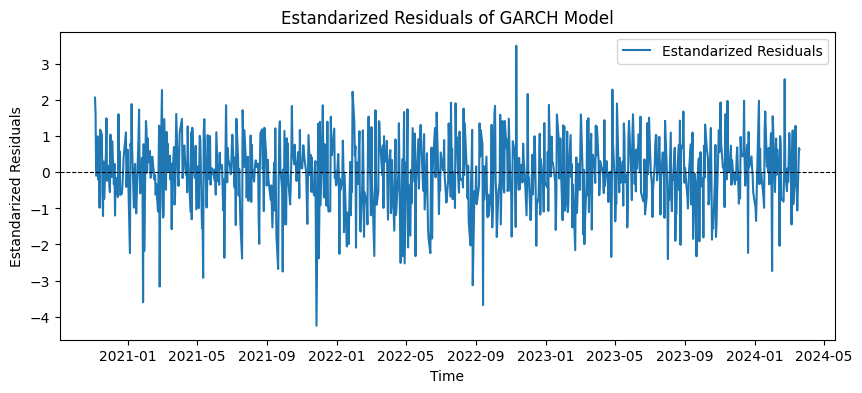

In [229]:
# Plot Estandarized residuals
plt.figure(figsize=(10, 4))
plt.plot(std_resid, label='Estandarized Residuals')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Estandarized Residuals of GARCH Model')
plt.xlabel('Time')
plt.ylabel('Estandarized Residuals')
plt.legend()
plt.show()


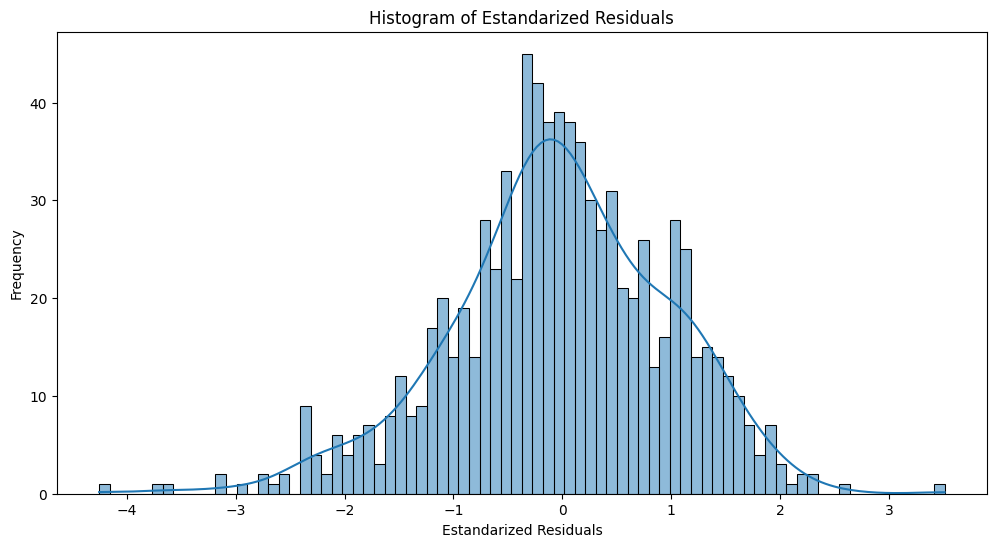

In [230]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(std_resid, bins=80, kde=True)
plt.title('Histogram of Estandarized Residuals')
plt.xlabel('Estandarized Residuals')
plt.ylabel('Frequency')
plt.show()


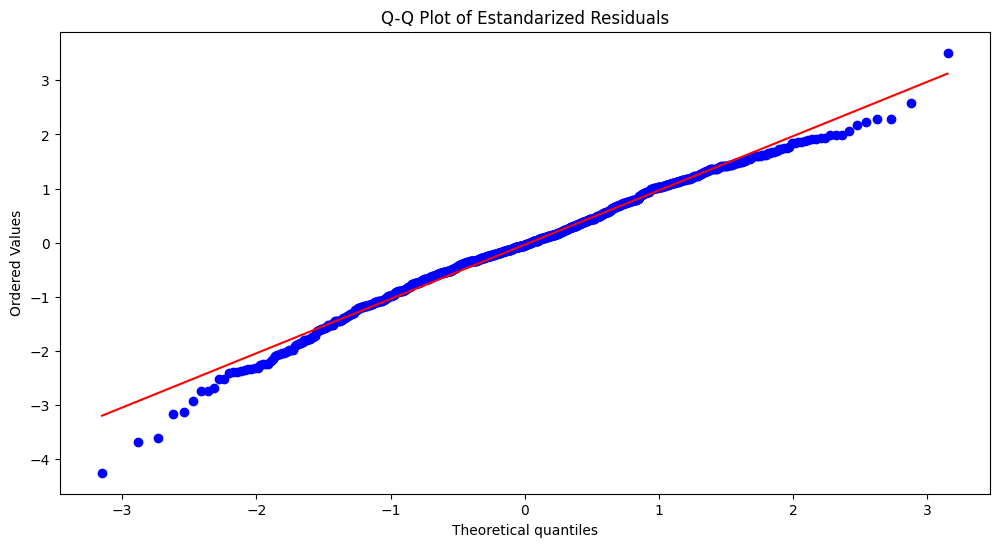

In [231]:
import scipy.stats as stats

plt.figure(figsize=(12, 6))
stats.probplot(std_resid, dist="norm", plot=plt)
plt.title('Q-Q Plot of Estandarized Residuals')
plt.show()


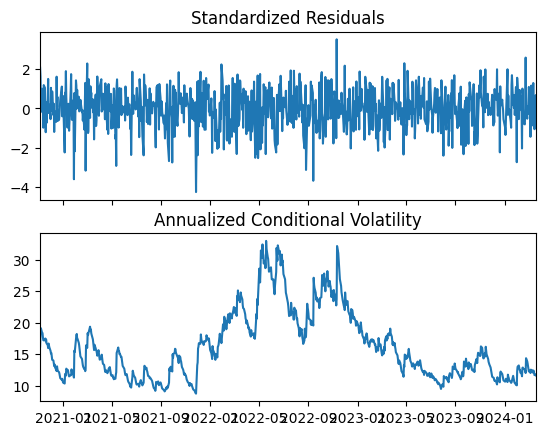

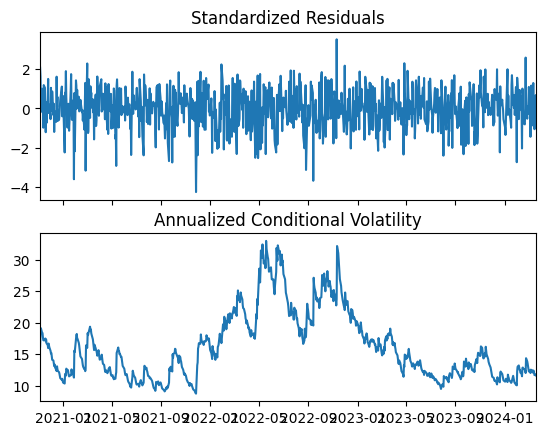

In [232]:
res_garch.plot(annualize="D")

Exponential GARCH

In [126]:
from arch import arch_model
import pandas as pd
from tqdm import tqdm  # Importar tqdm

results_list = []

p_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
q_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
distributions = ['normal', 't']

total_iterations = len(p_values) * len(q_values) * len(distributions)

with tqdm(total=total_iterations, desc='Fitting GARCH Models') as pbar:
    for p in p_values:
        for q in q_values:
            for dist in distributions:
                model = arch_model(y_train, mean='Zero', vol='EGARCH', p=p, q=q, dist=dist)
                res = model.fit(disp='off')
                
                results_list.append([
                    f'GARCH({p},{q})', p, q, dist, res.aic, res.bic])
                
                pbar.update(1)

results = pd.DataFrame(results_list, columns=['Model', 'p', 'q', 'Dist', 'AIC', 'BIC'])

best_model_aic = results.loc[results['AIC'].idxmin()]
best_model_bic = results.loc[results['BIC'].idxmin()]


Fitting GARCH Models: 100%|██████████| 162/162 [00:09<00:00, 17.31it/s]


In [127]:
# Fit GARCH (1,1)
# y_train, y_test = train_test_split(abs_returns, train_size= 0.8)

garch_mod = arch_model(y_train, mean = "Zero",  vol='EGARCH', p=1, q=1, rescale=False)
res_garch = garch_mod.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 6591.659455484303
Iteration:      2,   Func. Count:     13,   Neg. LLF: 241097235.15908614
Iteration:      3,   Func. Count:     21,   Neg. LLF: 1192.4408519440894
Iteration:      4,   Func. Count:     26,   Neg. LLF: 1189.399609190993
Iteration:      5,   Func. Count:     31,   Neg. LLF: 5619.4788429538
Iteration:      6,   Func. Count:     36,   Neg. LLF: 1189.5781506695716
Iteration:      7,   Func. Count:     41,   Neg. LLF: 1186.960267740641
Iteration:      8,   Func. Count:     45,   Neg. LLF: 1186.9468565854768
Iteration:      9,   Func. Count:     49,   Neg. LLF: 1186.9453562708593
Iteration:     10,   Func. Count:     53,   Neg. LLF: 1186.943021478492
Iteration:     11,   Func. Count:     57,   Neg. LLF: 1186.9429227559433
Iteration:     12,   Func. Count:     61,   Neg. LLF: 1186.9429056825843
Iteration:     13,   Func. Count:     64,   Neg. LLF: 1186.9429056816712
Optimization terminated successfully    (Exit mode 0)
    

In [128]:
# Model summary 
print(res_garch.summary())

                       Zero Mean - EGARCH Model Results                       
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                     EGARCH   Log-Likelihood:               -1186.94
Distribution:                  Normal   AIC:                           2379.89
Method:            Maximum Likelihood   BIC:                           2394.11
                                        No. Observations:                  847
Date:                Tue, Oct 22 2024   Df Residuals:                      847
Time:                        17:12:50   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      1.4988e-03  2.914e-03      0.514      0.607 

In [129]:
# Predict one step ahead

rolling_preds = []

for i in range(y_test.shape[0]):
    train = y_train[:-(y_test.shape[0]-i)]
    model = arch_model(train, mean='Zero', vol='EGARCH', p=p, q=q, dist=dist)
    model_fit = model.fit(disp='off')
    # One step ahead predictor
    pred = model_fit.forecast(horizon=1, reindex=True)
    rolling_preds.append(np.sqrt(pred.variance.values[-1,:][0]))

rolling_preds = pd.Series(rolling_preds, index=y_test.index)

Text(0.5, 1.0, 'SPY Rolling Volatility Prediction')

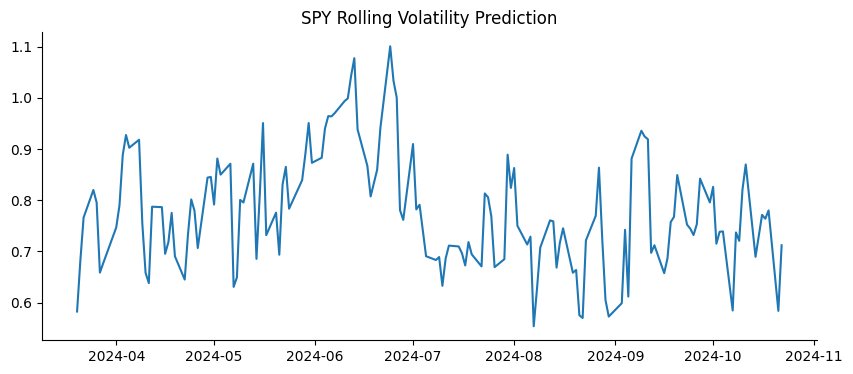

In [131]:
# Plot of predicted test data rolling volatility predictions
fig,ax = plt.subplots(figsize=(10,4))
ax.spines[['top','right']].set_visible(False)
plt.plot(rolling_preds)
plt.title(f'{ticker} Rolling Volatility Prediction')

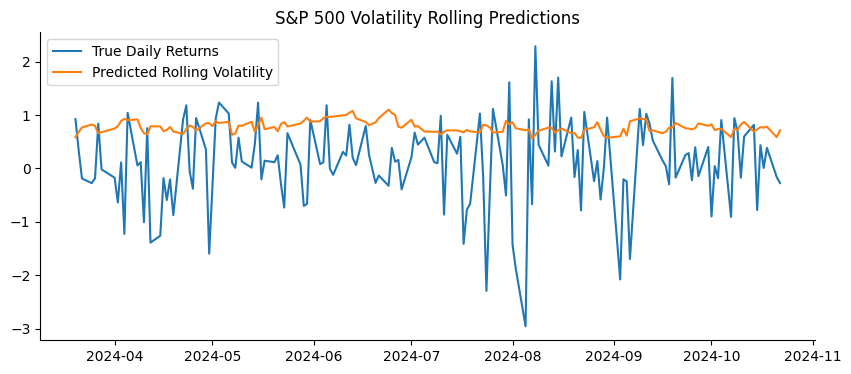

In [132]:
import matplotlib.pyplot as plt

fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.spines[['top', 'right']].set_visible(False)

ax2.plot(diff_ts[-y_test.shape[0]:])
ax2.plot(y_test.index, rolling_preds)
ax2.set_title("S&P 500 Volatility Rolling Predictions")
ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])

plt.show()


In [133]:
# Jarque-Bera test statistic

# H₀: The data has a normal distribution.
# Hₐ: The data does not have a normal distribution.


std_resid = res_garch.resid / res_garch.conditional_volatility

# Perform Jarque-Bera test using scipy.stats
jb_test = jarque_bera(std_resid)
print("Jarque-Bera test statistic:", jb_test[0])
print("p-value:", jb_test[1])

if jb_test[1].item() < 0.05:
    print("Reject H0: The data do not have statistical normal distribution")
else:
    print("No reject H0: Data have normal distribution.")

Jarque-Bera test statistic: 22.101692122909462
p-value: 1.5873713410864884e-05
Reject H0: The data do not have statistical normal distribution


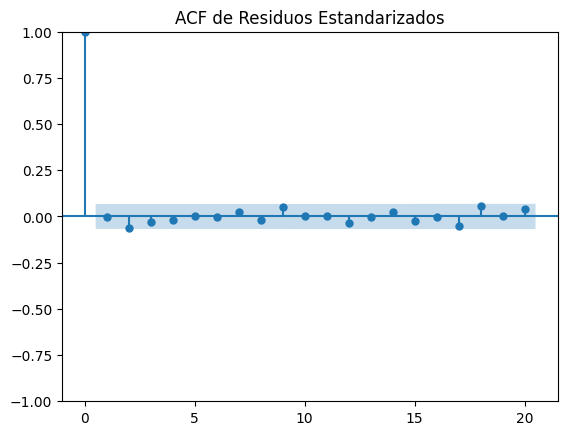

In [134]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(std_resid, lags=20)
plt.title("ACF de Residuos Estandarizados")
plt.show()


In [135]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(std_resid, lags=[10], return_df=True)
print(lb_test)


    lb_stat  lb_pvalue
10  7.42531   0.684775


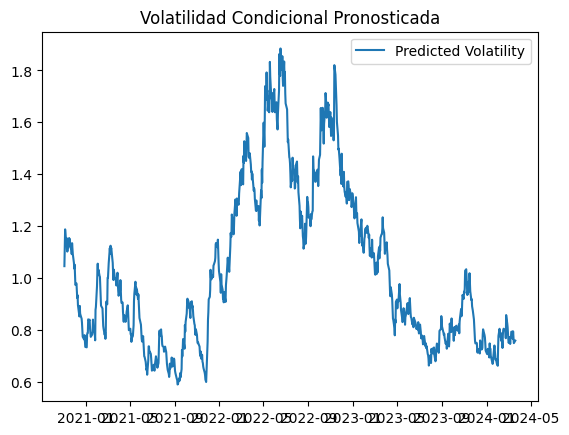

In [136]:
plt.plot(res_garch.conditional_volatility, label='Predicted Volatility')
plt.title("Volatilidad Condicional Pronosticada")
plt.legend()
plt.show()


In [137]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, rolling_preds)
print("MSE:", mse)


MSE: 1.1345374174517504


Quiebres en la serie

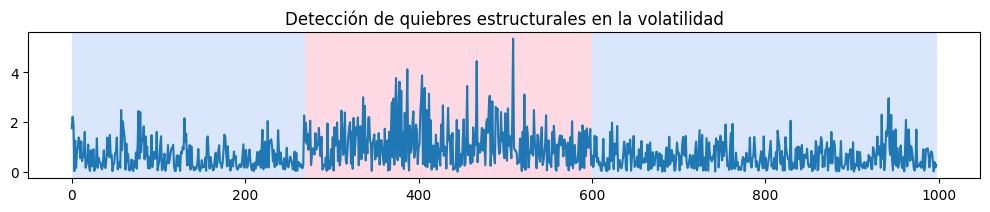

In [138]:
# Model L1  -> Modela distancia en valor absoluto desde la media 
# Model L2  -> Modela distancia al cuadrado desde la media
# Model rbf -> Modela Radial Basis Function

import ruptures as rpt
import matplotlib.pyplot as plt

log_return_array = abs(df['log_return']).values.reshape(-1, 1)

model = 'rbf'

algo = rpt.Pelt(model=model).fit(log_return_array)
breakpoints = algo.predict(pen=5)

# Visualizar los quiebres
rpt.display(abs(df['log_return']), breakpoints)
plt.title("Detección de quiebres estructurales en la volatilidad")
plt.show()
